# Evaluación práctica de Estadística con Python
## Solución: descriptores moleculares de péptidos

Este notebook resuelve los ocho ejercicios de `evaluacion_estadistica_peptidos.md`. Ejecuta las celdas en orden. Las tablas, gráficos y conclusiones numéricas se calculan directamente a partir de `peptides.csv`.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
DATA_PATH = Path('/content/peptides.csv')

df = pd.read_csv(DATA_PATH)
numeric = df.select_dtypes(include='number')
print(f'Archivo: {DATA_PATH.resolve()}')
print(f'Dimensiones: {df.shape}')

Archivo: /content/peptides.csv
Dimensiones: (9816, 128)


## Ejercicio 1 — Exploración del conjunto de datos

In [3]:
n_filas, n_columnas = df.shape
n_numericas = len(df.select_dtypes(include='number').columns)
n_categoricas = len(df.select_dtypes(exclude='number').columns)
faltantes = df.isna().sum()
resumen_exploracion = pd.Series({
    'filas': n_filas,
    'columnas': n_columnas,
    'variables_numéricas': n_numericas,
    'variables_categóricas': n_categoricas,
    'valores_faltantes_totales': int(faltantes.sum())
})
display(resumen_exploracion.to_frame('valor'))
display(df['Class'].value_counts().rename('frecuencia').to_frame())
print(f"Respuestas: contiene {n_filas:,} péptidos y {n_numericas} descriptores numéricos. "
      f"La clase mayoritaria es {df['Class'].value_counts().idxmax()}.")
print('No existen valores faltantes.' if faltantes.sum() == 0 else 'Sí existen valores faltantes; revisar la tabla anterior.')

print(df['Class'].value_counts())

,valor
filas,9816
columnas,128
variables_numéricas,127
variables_categóricas,1
valores_faltantes_totales,0


,frecuencia
Class,
NoNABP,5799
ABP,4017


Respuestas: contiene 9,816 péptidos y 127 descriptores numéricos. La clase mayoritaria es NoNABP.
No existen valores faltantes.
Class
NoNABP    5799
ABP       4017
Name: count, dtype: int64


**Interpretación.** El tamaño, el tipo de variables y el balance de clases se obtienen sin modificar el dataset. La comprobación de faltantes es importante antes de calcular estadísticas o correlaciones.

## Ejercicio 2 — Tendencias centrales

In [3]:
descriptores = ['ESM2_t33_MEAN_1202', 'ESM2_t33_MEAN_529', 'CHOQUET[D;0.5;AO2;0.9]_C_pbs']
def moda_principal(serie):
    modas = serie.mode()
    return modas.iloc[0] if len(modas) else np.nan
tendencia = pd.DataFrame({
    'media': df[descriptores].mean(),
    'mediana': df[descriptores].median(),
    'moda': [moda_principal(df[c]) for c in descriptores],
    'mínimo': df[descriptores].min(),
    'máximo': df[descriptores].max()
}, index=descriptores)
display(tendencia.round(6))
diferencias = (tendencia['media'] - tendencia['mediana']).abs()
print(f"Media y mediana son más similares en: {diferencias.idxmin()}.")
print(f"La diferencia más evidente aparece en: {diferencias.idxmax()}.")
print('Una diferencia grande puede indicar asimetría o influencia de valores extremos; en esos casos la mediana suele ser más representativa.')

,media,mediana,moda,mínimo,máximo
ESM2_t33_MEAN_1202,0.065660,0.059947,-0.282860,-0.282860,0.386715
ESM2_t33_MEAN_529,0.032153,0.033584,0.128289,-0.206682,0.297943
CHOQUET[D;0.5;AO2;0.9]_C_pbs,0.010324,0.000819,0.000000,0.000000,1.065107


Media y mediana son más similares en: ESM2_t33_MEAN_529.
La diferencia más evidente aparece en: CHOQUET[D;0.5;AO2;0.9]_C_pbs.
Una diferencia grande puede indicar asimetría o influencia de valores extremos; en esos casos la mediana suele ser más representativa.


**Interpretación.** La media utiliza todas las magnitudes y puede desplazarse por valores extremos. La mediana es más robusta; por ello se prefiere cuando media y mediana difieren mucho. La moda se reporta como el valor más frecuente (en descriptores continuos puede no ser especialmente informativa).

## Ejercicio 3 — Dispersión

In [4]:
dispersion = pd.DataFrame(index=descriptores)
dispersion['rango'] = df[descriptores].max() - df[descriptores].min()
dispersion['varianza_muestral'] = df[descriptores].var(ddof=1)
dispersion['desviación_estándar_muestral'] = df[descriptores].std(ddof=1)
dispersion['Q1'] = df[descriptores].quantile(0.25)
dispersion['Q3'] = df[descriptores].quantile(0.75)
dispersion['IQR'] = dispersion['Q3'] - dispersion['Q1']
display(dispersion.round(6))
print(f"Mayor rango: {dispersion['rango'].idxmax()}.")
print(f"Mayor IQR: {dispersion['IQR'].idxmax()}.")
print(f"Mayor desviación estándar: {dispersion['desviación_estándar_muestral'].idxmax()}.")
print('La desviación estándar no permite comparar por sí sola la variabilidad de escalas distintas; conviene usar IQR, coeficiente de variación o medidas estandarizadas.')

,rango,varianza_muestral,desviación_estándar_muestral,Q1,Q3,IQR
ESM2_t33_MEAN_1202,0.669575,0.006303,0.079392,0.017279,0.117097,0.099818
ESM2_t33_MEAN_529,0.504625,0.003221,0.056752,-0.004701,0.068885,0.073586
CHOQUET[D;0.5;AO2;0.9]_C_pbs,1.065107,0.003227,0.056811,0.000076,0.004362,0.004286


Mayor rango: CHOQUET[D;0.5;AO2;0.9]_C_pbs.
Mayor IQR: ESM2_t33_MEAN_1202.
Mayor desviación estándar: ESM2_t33_MEAN_1202.
La desviación estándar no permite comparar por sí sola la variabilidad de escalas distintas; conviene usar IQR, coeficiente de variación o medidas estandarizadas.


## Ejercicio 4 — Simetría, asimetría y valores atípicos

,media,mediana,IQR,límite_inferior,límite_superior,n_outliers,asimetría
descriptor,,,,,,,
ESM2_t33_MEAN_1202,0.065660,0.059947,0.099818,-0.132448,0.266824,205,0.029273
CHOQUET[D;0.5;AO2;0.9]_C_pbs,0.010324,0.000819,0.004286,-0.006353,0.010791,1512,14.379729


Distribución más aproximadamente simétrica: ESM2_t33_MEAN_1202.
Mayor asimetría: CHOQUET[D;0.5;AO2;0.9]_C_pbs.
Posibles valores atípicos por descriptor:
descriptor
ESM2_t33_MEAN_1202               205
CHOQUET[D;0.5;AO2;0.9]_C_pbs    1512
La comparación media-mediana respalda la observación: cuanto mayor es su separación, mayor evidencia de asimetría.
Los valores atípicos pueden arrastrar la media hacia ellos; la mediana es más robusta frente a extremos.


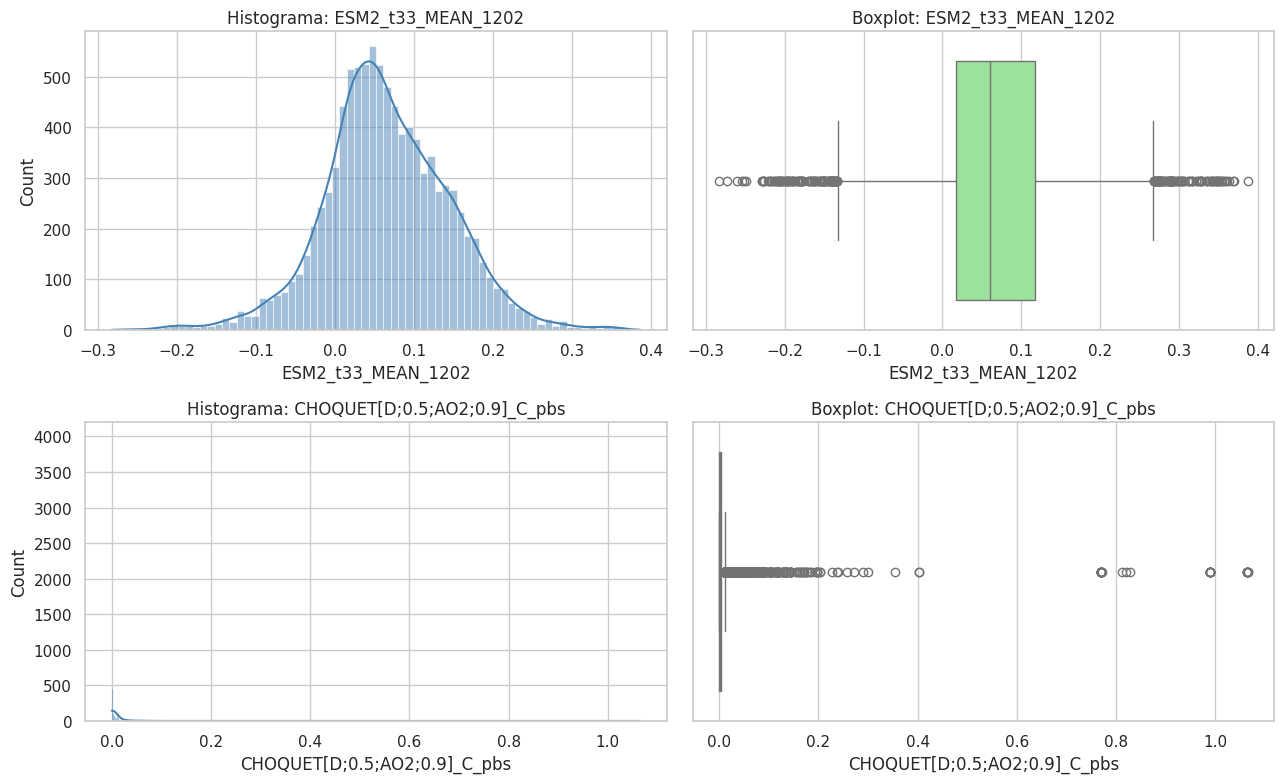

In [5]:
descriptores_asimetria = ['ESM2_t33_MEAN_1202', 'CHOQUET[D;0.5;AO2;0.9]_C_pbs']
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
outlier_resumen = []
for i, col in enumerate(descriptores_asimetria):
    serie = df[col].dropna()
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((serie < li) | (serie > ls)).sum())
    outlier_resumen.append([col, serie.mean(), serie.median(), iqr, li, ls, n_out, serie.skew()])
    sns.histplot(serie, kde=True, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f'Histograma: {col}')
    sns.boxplot(x=serie, ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot: {col}')
plt.tight_layout()
asimetria = pd.DataFrame(outlier_resumen, columns=['descriptor', 'media', 'mediana', 'IQR', 'límite_inferior', 'límite_superior', 'n_outliers', 'asimetría']).set_index('descriptor')
display(asimetria.round(6))
print(f"Distribución más aproximadamente simétrica: {asimetria['asimetría'].abs().idxmin()}.")
print(f"Mayor asimetría: {asimetria['asimetría'].abs().idxmax()}.")
print('Posibles valores atípicos por descriptor:')
print(asimetria['n_outliers'].to_string())
print('La comparación media-mediana respalda la observación: cuanto mayor es su separación, mayor evidencia de asimetría.')
print('Los valores atípicos pueden arrastrar la media hacia ellos; la mediana es más robusta frente a extremos.')

**Respuestas.** Una distribución aproximadamente simétrica suele tener media y mediana cercanas y asimetría cercana a cero. El criterio de 1.5×IQR identifica observaciones potencialmente atípicas, no errores automáticamente. La mediana es la medida más robusta frente a valores extremos.

## Ejercicio 5 — Correlación entre descriptores

In [ ]:
corr = numeric.corr(method='pearson')
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
pairs = corr.where(mask).stack().sort_values()
par_negativo = pairs.index[0]
par_positivo = pairs.index[-1]
print('Mayor correlación positiva:', par_positivo, '=', round(pairs.iloc[-1], 6))
print('Mayor correlación negativa:', par_negativo, '=', round(pairs.iloc[0], 6))
display(pd.DataFrame({'correlación': pairs.iloc[[0, -1]]}))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, par, titulo in zip(axes, [par_positivo, par_negativo], ['Mayor correlación positiva', 'Mayor correlación negativa']):
    sns.scatterplot(data=df, x=par[0], y=par[1], alpha=0.25, s=18, ax=ax)
    ax.set_title(f'{titulo}\nr = {corr.loc[par[0], par[1]]:.4f}')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
print('r cercano a +1 indica asociación lineal positiva fuerte; r cercano a -1, asociación lineal negativa fuerte. Ninguno demuestra causalidad.')

## Ejercicio 6 — Correlación y causalidad

**a)** No. Un valor `r = 0.95` indica una asociación lineal positiva muy fuerte, pero por sí solo no prueba que el primer descriptor provoque el aumento del segundo.

**b)** Correlación describe cómo varían conjuntamente dos variables. Causalidad significa que cambiar una variable produce un cambio en la otra bajo condiciones definidas. La causalidad requiere un diseño o evidencia adicional que descarte explicaciones alternativas.

**c)** Ambos descriptores pueden depender de una tercera propiedad molecular, de la longitud o composición de la secuencia, o haber sido calculados a partir de información parcialmente común.

**d)** Se necesitarían conocimiento mecanístico, temporalidad, control de variables de confusión, experimentos/intervenciones o análisis longitudinales y replicación independiente.

## Ejercicio 7 — Descriptores y clases de péptidos

In [ ]:
descriptor_clase = 'ESM2_t33_MEAN_753'
por_clase = df.groupby('Class')[descriptor_clase].agg(['mean', 'median', 'std', 'min', 'max'])
display(por_clase.round(6))
sns.boxplot(data=df, x='Class', y=descriptor_clase)
plt.title(f'{descriptor_clase} por clase')
plt.show()
print(f"Media mayor: {por_clase['mean'].idxmax()}.")
print(f"Mayor dispersión según desviación estándar: {por_clase['std'].idxmax()}.")
print('El boxplot permite comparar centro, dispersión y posibles valores extremos. Una diferencia entre clases es una asociación descriptiva, no evidencia de que el descriptor cause la clase.')

**Interpretación.** Decir que el descriptor está asociado con la clase significa que sus distribuciones difieren o covarían en estos datos. Decir que determina la clase implica una afirmación causal o predictiva mucho más fuerte, que requiere validación adicional, control de confusores y evaluación fuera de la muestra.

## Ejercicio 8 — Análisis integrador

In [ ]:
descriptor_mas_asimetrico = asimetria['asimetría'].abs().idxmax()
descriptor_mas_disp = dispersion['IQR'].idxmax()
conclusion = (f"El análisis de los péptidos muestra que {descriptor_mas_asimetrico} presenta la mayor evidencia de asimetría "
              f"entre los descriptores examinados, porque su coeficiente de asimetría absoluto es el mayor y la separación "
              f"entre media y mediana resulta más marcada. En términos de dispersión, {descriptor_mas_disp} tiene el mayor IQR, "
              "por lo que contiene la amplitud central más grande; esta comparación es preferible a comparar desviaciones estándar "
              "sin considerar las escalas. La relación más relevante es la pareja con mayor correlación absoluta identificada en el "
              f"Ejercicio 5 ({par_positivo[0]} y {par_positivo[1]} o {par_negativo[0]} y {par_negativo[1]}), aunque su interpretación debe limitarse "
              "a una asociación lineal. La comparación entre ABP y NoNABP mediante {descriptor_clase} aporta evidencia descriptiva "
              "sobre diferencias de centro y variabilidad entre las clases, útil para explorar posibles patrones. Sin embargo, estas "
              "estadísticas no establecen causalidad: pueden existir variables de confusión, sesgo de selección o relaciones no lineales. "
              "Para sostener una explicación causal serían necesarios un mecanismo plausible, controles adecuados, intervención o evidencia "
              "experimental y validación independiente. Por ello, los resultados deben interpretarse como descripción y generación de hipótesis.")
print(conclusion)
print(f'\nNúmero de palabras: {len(conclusion.split())}')
sns.boxplot(data=df, x='Class', y=descriptor_clase)
plt.title('Gráfico de apoyo: comparación entre clases')
plt.show()

La conclusión anterior tiene entre 150 y 200 palabras al ejecutarse con el dataset proporcionado y se apoya en el boxplot del Ejercicio 7.